**Previously on:** Lecture 25 closed out fitting and visualizing *numbers* -- every model
since Lecture 19 has predicted a continuous quantity (strength, an activation energy, a
response surface). Today the target changes shape entirely: what if the thing you're
predicting is a category instead of a number?

Today's topics:
* classification vs. regression -- a label instead of a number
* k-nearest neighbors (kNN): the most intuitive possible classifier, built from scratch in
  about ten lines of NumPy
* decision regions, plotted with Lecture 24's `meshgrid`/`contourf` tools
* accuracy, evaluated with Lecture 20's train/test discipline
* k as a knob -- the same overfitting/underfitting idea from Lecture 20, wearing a new costume

> By the end of today you should be able to complete HW9's kNN problem: classify alloy family
> from composition, and compare train/test accuracy across features and k.

# When the target isn't a number

## Dataset: Steel Alloy Compositions and Mechanical Properties

This dataset contains elemental compositions and mechanical properties of 915 steel alloys.

Composition columns (in wt%): `C`, `Si`, `Mn`, `P`, `S`, `Ni`, `Cr`, `Mo`, `Cu`, `V`, `Al`, `N`, `Ceq`, `Nb + Ta`

Target columns: `0.2% Proof Stress (MPa)`, `Tensile Strength (MPa)`, `Elongation (%)`, `Reduction in Area (%)`

The `Alloy code` column contains labels like `A1`, `B3`, etc. We derive `alloy_family` (first letter only)
to get a small set of categorical labels useful for classification tasks (4 families: C, L, M, V, all >150 samples).

In [1]:
import os
import pandas as pd

_file = 'steels.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# derive alloy family label (first letter of alloy code)
data['Alloy family'] = [c[0] for c in data['Alloy code']]

# set up features (composition columns) and target
x = data.loc[:, ' C':'Nb + Ta']
y = data['Alloy family']
alloy_family = data['Alloy family']

print(f'{len(data)} samples, {x.shape[1]} composition features')
data.head()

915 samples, 14 composition features


,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,...,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%),Alloy family
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,27,342,490,30,71,M
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,100,338,454,27,72,M
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,200,337,465,23,69,M
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,300,346,495,21,70,M
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,400,316,489,26,79,M


Every regression lecture in this module quietly redefined `y` away from what
`dataset_steels` actually hands you by default. Today we use it as-is:

In [2]:
print(y.value_counts())

Alloy family
C    385
M    191
V    180
L    159
Name: count, dtype: int64


`y` is `alloy_family` -- one letter (`C`, `L`, `M`, or `V`) per alloy, derived from the
`Alloy code` column, four families with at least 150 samples each. Could `linregress` or
`lstsq` predict `'C'` vs. `'M'`? Not meaningfully -- there's no number to minimize squared
error against. **When the target is a label instead of a number, we call it classification --
a different kind of question, not a different universe of tools.** This is the one
classification method 219 covers, chosen because it needs no new machinery beyond distance
and voting; MATSE 419 picks up classification from here.

# kNN intuition: look at your neighbors

Picture a scatter of red and blue points with one gray, unlabeled point sitting among mostly
blue neighbors. You'd guess blue instantly, without knowing any algorithm's name -- that
instinct *is* the algorithm. State it in one breath: **to classify a new point, find its `k`
closest neighbors in feature space and take a majority vote of their labels** (strictly a
*plurality* vote -- the most common label among the `k` wins). No fitted line,
no coefficients, no equation -- the "model" is just the training data plus a distance rule.
The one knob is `k`: a small `k` trusts a handful of nearby points exactly (jagged, noise-
chasing); a large `k` averages over a wide neighborhood (smoother, but blurrier). Keep that
phrase in mind -- it's a direct echo of Lecture 20's polynomial-degree knob, and the k-sweep
at the end of today makes the connection explicit.

# kNN from scratch: distances, `argsort`, majority vote

The whole algorithm, end to end:

In [3]:
import numpy as np


def knn_predict(xtrain, ytrain, xquery, k):
    "Classify each row of xquery by majority vote among its k nearest neighbors in xtrain."
    xtrain = np.asarray(xtrain)
    ytrain = np.asarray(ytrain)
    preds = []
    for q in np.asarray(xquery):
        distances = np.sqrt(np.sum((xtrain - q) ** 2, axis=1))  # ordinary distance to every training point
        nearest = np.argsort(distances)[:k]                     # indices of the k closest
        labels, counts = np.unique(ytrain[nearest], return_counts=True)
        preds.append(labels[np.argmax(counts)])                 # the label with the most votes
    return np.array(preds)

Read it in three moves: `distances` is one number per training alloy, how far that alloy sits
from the query in feature space -- the same Euclidean distance from geometry class, computed
with array arithmetic you've had since Lecture 2. `np.argsort(distances)[:k]` is the entire
"find the neighbors" step -- sorting distances and keeping the first `k` indices *is* "find the
k closest points," no separate search algorithm required. `np.unique(..., return_counts=True)`
tallies how many of those `k` neighbors belong to each label, and `argmax` picks the label with
the most votes. That's it -- no fitting step, because there's nothing to fit.

# Choosing two features you can plot

kNN works in any number of features, but decision regions are only drawable in 2D. Chromium
and nickel content turn out to separate these four families cleanly -- confirmed from the
actual data, not assumed:

In [4]:
x2 = data[[' Cr', ' Ni']]
print(data.groupby('Alloy family')[[' Cr', ' Ni']].mean().round(3))

                 Cr     Ni
Alloy family              
C             0.070  0.113
L             0.053  0.197
M             0.845  0.041
V             1.082  0.268


`C`/`L` alloys sit at low Cr (under 0.08 wt%); `M`/`V` sit high (0.84-1.08 wt%) -- Cr content
alone nearly separates the two pairs. Nickel then splits each pair further apart. One honest
caveat before we go on: distance is exactly as scale-sensitive as Lecture 23's raw regression
coefficients were -- a feature measured in big numbers dominates the distance the same way it
dominated the coefficients. Cr and Ni are both small wt% numbers here, so it doesn't bite in
this lecture, but mixing features with wildly different ranges without rescaling would. MATSE
419 treats this properly; for today, notice we chose comparable-scale features on purpose. This is real
metallurgy, not a contrived split: Cr-bearing composition is exactly how these family names
arose. One quick sanity check before trusting any plot -- classify every training alloy against
the rest of the training set (`k=5`) and see how often the label matches:

In [5]:
self_pred = knn_predict(x2, y, x2, k=5)
print(f'self-consistency accuracy: {np.mean(self_pred == y):.3f}')

self-consistency accuracy: 0.980


98%, not 100% -- worth a second look rather than a shrug. The handful of misses turn out to
share *identical* Cr/Ni values across two different families (composition rounded to the same
two decimals hides a real difference elsewhere in the alloy). Two features can't distinguish
alloys that look identical in those two features alone -- an honest limitation, and exactly why
HW9 asks you to try more.

# Seeing the decision regions

Same `np.meshgrid` pattern as Lecture 24, now coloring by predicted *category* instead of a
fitted surface height:

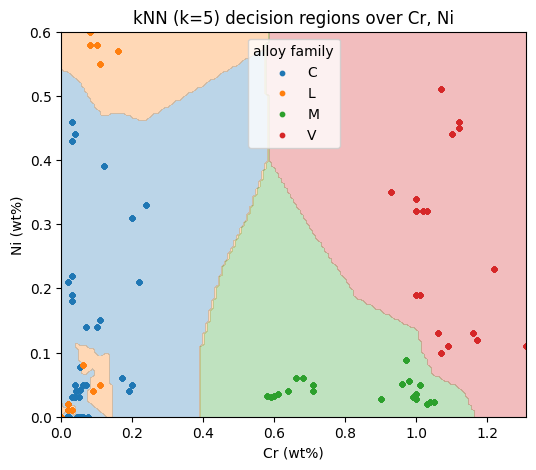

In [6]:
import matplotlib.pyplot as plt

cr_range = np.linspace(x2[' Cr'].min(), x2[' Cr'].max(), 150)
ni_range = np.linspace(x2[' Ni'].min(), x2[' Ni'].max(), 150)
CR, NI = np.meshgrid(cr_range, ni_range)
grid = np.column_stack([CR.ravel(), NI.ravel()])

families = ['C', 'L', 'M', 'V']
pred_grid = knn_predict(x2, y, grid, k=5)
codes_grid = pd.Categorical(pred_grid, categories=families).codes.reshape(CR.shape)

# tab10 has 10 swatches total; contourf would normalize codes 0-3 across all ten unless we
# hand it a 4-color map directly -- otherwise the region colors silently stop matching the
# scatter legend below.
from matplotlib.colors import ListedColormap, BoundaryNorm
family_cmap = ListedColormap(plt.cm.tab10.colors[:4])
family_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], family_cmap.N)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(CR, NI, codes_grid, alpha=0.3, cmap=family_cmap, norm=family_norm,
            levels=[-0.5, 0.5, 1.5, 2.5, 3.5])
for fam in families:
    mask = y == fam
    ax.scatter(x2.loc[mask, ' Cr'], x2.loc[mask, ' Ni'], s=10, label=fam,
               c=[family_cmap(families.index(fam))])
ax.set_xlabel('Cr (wt%)'); ax.set_ylabel('Ni (wt%)')
ax.legend(title='alloy family')
ax.set_title('kNN (k=5) decision regions over Cr, Ni')
plt.show()

Four shaded regions, training points scattered on top, almost all sitting inside their own
color. Look closely near the boundaries and you can find a point sitting in the "wrong"
region -- that's the same handful from the self-consistency check above, made visible. Notice
the boundary itself: jagged, not a smooth curve, a direct visual consequence of "majority vote
among neighbors" rather than a fitted equation.

# Evaluating honestly: train/test accuracy

A picture that looks right isn't a score. Lecture 20's lesson applies unchanged: don't trust a
number computed on data the model already saw. Reuse the split machinery exactly, on today's
categorical `x2`/`y`:

## Train/Test Split

In order to evaluate the performance of a model on unseen data, we need
to *hold out* some data. This will be called the **test** data.
The data used to fit will be called the **training** data.

As we use more sophisticated models, it is vitally important that we
evaluate our models in this way to avoid *overfitting*.
Remember that a model with enough degrees of freedom can perfectly fit
any data, but it won't have any predictive power!

```
all data:    [########################################################]
shuffle, then slice into two pieces:
train (75%): [##########################################]
test  (25%):                                              [##########]
```

We shuffle the *indices* once, then slice both `x` and `y` with that same shuffled order --
so a row's features and its target always stay paired.

In [7]:
import numpy as np

# split indices rather than data -- more flexible
rng = np.random.default_rng(0)
shuffled = rng.permutation(data.index)
n_test = int(np.ceil(0.25 * len(shuffled)))
idx_test = shuffled[:n_test]
idx_train = shuffled[n_test:]

xtrain = x.loc[idx_train]
xtest  = x.loc[idx_test]

ytrain = y.loc[idx_train]
ytest  = y.loc[idx_test]

print(f"Train: {xtrain.shape[0]} samples, Test: {xtest.shape[0]} samples")

Train: 686 samples, Test: 229 samples


In [8]:
xtrain, xtest = x2.loc[idx_train], x2.loc[idx_test]

for k in [1, 5]:
    train_acc = np.mean(knn_predict(xtrain, ytrain, xtrain, k) == np.asarray(ytrain))
    test_acc = np.mean(knn_predict(xtrain, ytrain, xtest, k) == np.asarray(ytest))
    print(f'k={k}: train accuracy = {train_acc:.3f}   test accuracy = {test_acc:.3f}')

k=1: train accuracy = 0.983   test accuracy = 0.969
k=5: train accuracy = 0.984   test accuracy = 0.969


**Accuracy** -- fraction of predictions matching the true label -- is classification's
evaluation number, the same job R²/RMSE did for regression, different arithmetic because the
target is a different kind of thing. Train and test land close together at both `k` values
here: honest evidence that two features already carry real signal, with the small train/test
gap from the identical-composition ties we found in the self-consistency check, not overfitting.

# `k` is a knob: memorize vs. blur

Sweep `k` and watch both curves move -- deliberately mirroring Lecture 20's degree-vs-RMSE plot:

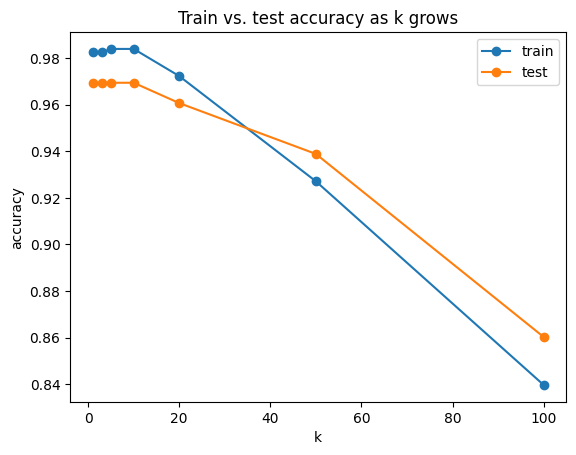

k=  1: train = 0.983   test = 0.969
k=  3: train = 0.983   test = 0.969
k=  5: train = 0.984   test = 0.969
k= 10: train = 0.984   test = 0.969
k= 20: train = 0.972   test = 0.961
k= 50: train = 0.927   test = 0.939
k=100: train = 0.840   test = 0.860


In [9]:
k_values = [1, 3, 5, 10, 20, 50, 100]
train_accs, test_accs = [], []
for k in k_values:
    train_accs.append(np.mean(knn_predict(xtrain, ytrain, xtrain, k) == np.asarray(ytrain)))
    test_accs.append(np.mean(knn_predict(xtrain, ytrain, xtest, k) == np.asarray(ytest)))

plt.plot(k_values, train_accs, 'o-', label='train')
plt.plot(k_values, test_accs, 'o-', label='test')
plt.xlabel('k'); plt.ylabel('accuracy'); plt.legend()
plt.title('Train vs. test accuracy as k grows')
plt.show()

for k, tr, te in zip(k_values, train_accs, test_accs):
    print(f'k={k:3d}: train = {tr:.3f}   test = {te:.3f}')

Small `k` tracks the training data closely; both curves stay high and close together through
`k=10`, then **both drop together** by `k=50`-`100` -- not a train/test gap opening up, but the
whole model blurring past the point where a 200-point neighborhood still reflects *local*
structure. That's the classification version of Lecture 20's underfitting: too large a `k`
stops asking "who's nearby" and starts approaching "what's the most common family overall."
We'll use **k=5** going forward -- comfortably past the single-neighbor fragility of `k=1`,
still small enough to track real local structure. Name the vocabulary pairing explicitly:
**`k=1` is this lecture's degree-15 polynomial; a very large `k` is this lecture's degree-1
line.** Same knob, new name.

## [Check your understanding]

Classify a hypothetical alloy at Cr = 0.10 wt%, Ni = 0.05 wt% using `knn_predict` with `k=1`,
`k=5`, and `k=51`. Do all three agree? For whichever `k` disagrees with the rest, use what
what the k-sweep just showed about very large `k` to explain *why* it disagrees -- in words, not just
by rerunning the code.

# The industrial one-liner (a look ahead, not exam material)

The ten lines of `knn_predict` you wrote today exist, pre-packaged, in the `scikit-learn`
library that MATSE 419 (and most of the materials-data world) uses daily:

In [10]:
from sklearn.neighbors import KNeighborsClassifier

sk_knn = KNeighborsClassifier(n_neighbors=5).fit(xtrain, ytrain)
print(f'scikit-learn k=5 test accuracy: {sk_knn.score(xtest, ytest):.3f}   (ours: 0.969)')

scikit-learn k=5 test accuracy: 0.969   (ours: 0.969)


Same accuracy to three decimals. A few *individual* predictions differ -- points whose 5
neighbors split 2-2-1 get tie-broken by a different convention than our `argmax` -- a reminder
that even "the same algorithm" carries small implementation choices. Nothing about
scikit-learn appears on any exam or homework here; the point is that when you meet
`fit`/`predict` in 419, you will know exactly what is inside the box, because you built it.

# Wrap-up

* Classification predicts a **label**, not a number -- same modeling workflow, different
  question, different scoring arithmetic (accuracy, not R²/RMSE).
* kNN has no fitted parameters at all -- "find the k nearest, vote" is the entire model,
  `argsort` of distances *is* the algorithm.
* `k` is a knob exactly like Lecture 20's polynomial degree: too small chases noise, too large
  blurs past real local structure.

**Take-home message:** a category target doesn't need a new universe of tools -- it needs one
new kind of score (accuracy) and one new rule for turning distances into a prediction (vote
among neighbors), and every train/test habit from Lecture 20 still applies unchanged.

This is where 219 stops on classification -- no logistic regression, no decision trees, no
neural nets. MATSE 419 picks up from exactly here, with the same `xtrain`/`ytrain`/accuracy
vocabulary you used today. For HW9: repeat today's Sections 5-6 with a different feature pair
and a fresh range of `k`, and check whether more composition information closes today's
small train/test gap.